# Dissertation Title : Evaluation of a Machine Learning-Based Employee Salary Prediction Prototype Using Multiple Regression Models and Hyperparameter Optimisation

# Importing Libraries , Loading the Dataset & Basic Few Operations

In [ ]:
# I imported the NumPy library for performing numerical computations.
import numpy as np

# I imported the Pandas library for loading and manipulating the dataset.
import pandas as pd

# I imported the Matplotlib library for creating visualisations.
import matplotlib.pyplot as plt

# I imported the Seaborn library for generating statistical visualisations.
import seaborn as sns

# I loaded the dataset into a Pandas DataFrame.
df = pd.read_csv("Employers_data.csv")

# I displayed the first five records of the dataset.
print("First Five Records:")
print(df.head())

# I displayed the dimensions of the dataset.
print("\nDataset Shape:")
print(df.shape)

# I displayed the data types of all attributes.
print("\nData Types:")
print(df.dtypes)

First Five Records:
   Employee_ID            Name  Age  Gender   Department  Job_Title  \
0            1    Merle Ingram   24  Female  Engineering   Engineer   
1            2      John Mayes   56    Male        Sales  Executive   
2            3    Carlos Wille   21    Male  Engineering     Intern   
3            4  Michael Bryant   30    Male      Finance    Analyst   
4            5   Paula Douglas   25  Female           HR    Analyst   

   Experience_Years Education_Level  Location  Salary  
0                 1          Master    Austin   90000  
1                33          Master   Seattle  195000  
2                 1        Bachelor  New York   35000  
3                 9        Bachelor  New York   75000  
4                 2          Master   Seattle   70000  

Dataset Shape:
(10000, 10)

Data Types:
Employee_ID          int64
Name                object
Age                  int64
Gender              object
Department          object
Job_Title           object
Experience_Yea

# Data Inspection

In [ ]:
# I identified the target variable in the dataset.
target_variable = "Salary"

# I identified the independent variables.
independent_variables = df.drop(columns=[target_variable]).columns.tolist()

# I displayed the total number of observations in the dataset.
print("Number of Observations:", df.shape[0])

# I displayed the total number of features in the dataset.
print("Number of Features:", df.shape[1])

# I displayed the target variable.
print("\nTarget Variable:")
print(target_variable)

# I displayed the independent variables.
print("\nIndependent Variables:")
print(independent_variables)

# I displayed the total number of independent variables.
print("\nNumber of Independent Variables:", len(independent_variables))

Number of Observations: 10000
Number of Features: 10

Target Variable:
Salary

Independent Variables:
['Employee_ID', 'Name', 'Age', 'Gender', 'Department', 'Job_Title', 'Experience_Years', 'Education_Level', 'Location']

Number of Independent Variables: 9


# Data Pre-Processing

In [ ]:
# I checked for missing values in the dataset.
print("Missing Values Before Preprocessing:")
print(df.isnull().sum())

# I removed the 'Employee_ID' attribute because it was a unique identifier and did not contribute to salary prediction.
# I removed the 'Name' attribute because it contained personally identifiable information.
# I removed the 'Gender' attribute because it lead to algorithmic bias.
df = df.drop(columns=["Employee_ID", "Name", "Gender"])

# I displayed the dimensions of the preprocessed dataset.
print("\nPreprocessed Dataset Shape:")
print(df.shape)

# I verified the missing values after preprocessing.
print("\nMissing Values After Preprocessing:")
print(df.isnull().sum())


# I displayed the first five records of the preprocessed dataset.
print("\nFirst Five Records of the Preprocessed Dataset:")
print(df.head())

Missing Values Before Preprocessing:
Employee_ID         0
Name                0
Age                 0
Gender              0
Department          0
Job_Title           0
Experience_Years    0
Education_Level     0
Location            0
Salary              0
dtype: int64

Preprocessed Dataset Shape:
(10000, 7)

Missing Values After Preprocessing:
Age                 0
Department          0
Job_Title           0
Experience_Years    0
Education_Level     0
Location            0
Salary              0
dtype: int64

First Five Records of the Preprocessed Dataset:
   Age   Department  Job_Title  Experience_Years Education_Level  Location  \
0   24  Engineering   Engineer                 1          Master    Austin   
1   56        Sales  Executive                33          Master   Seattle   
2   21  Engineering     Intern                 1        Bachelor  New York   
3   30      Finance    Analyst                 9        Bachelor  New York   
4   25           HR    Analyst                 

# Exploratory Data Analysis (EDA)

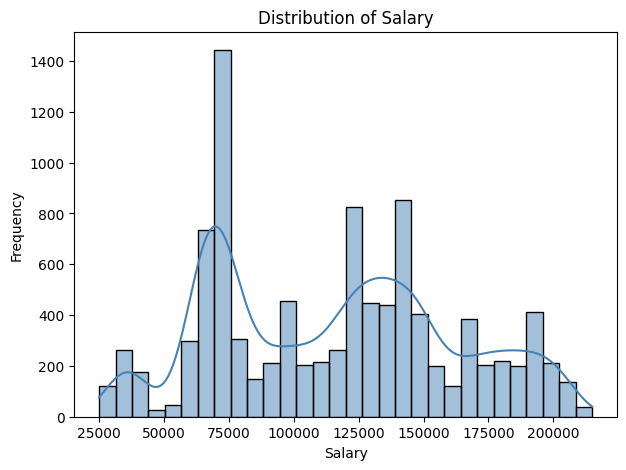

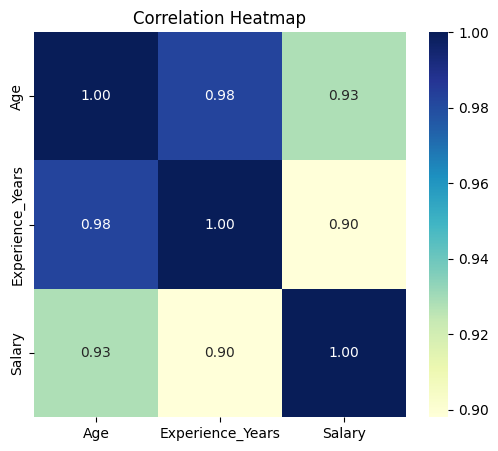

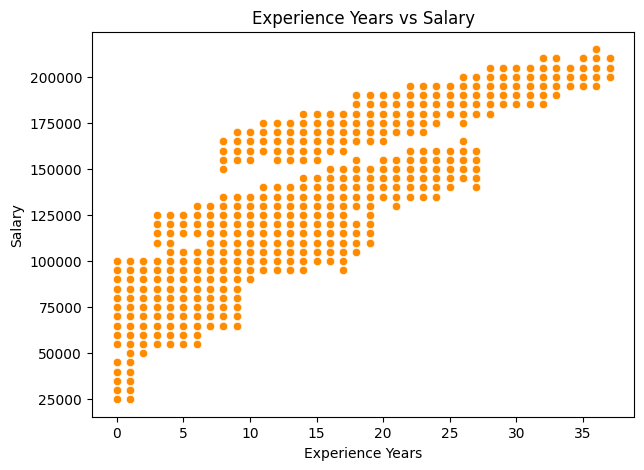

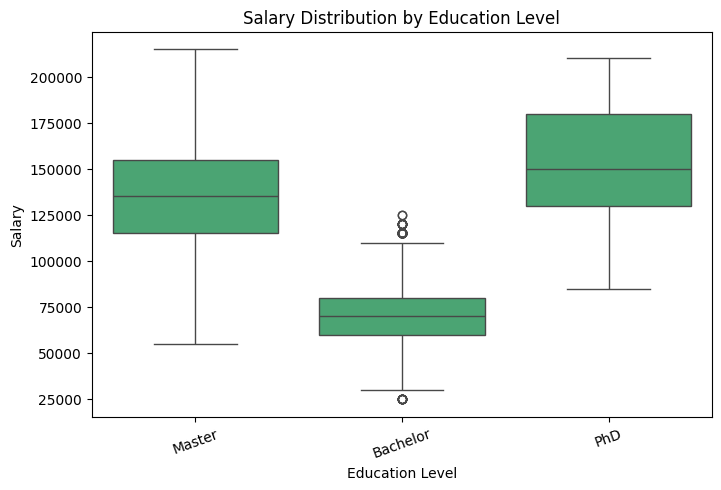

In [ ]:
# I visualised the distribution of the target variable.
plt.figure(figsize=(7,5))
sns.histplot(df["Salary"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of Salary")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

# I analysed the correlations among the numerical attributes.
plt.figure(figsize=(6,5))
sns.heatmap(
    df[["Age", "Experience_Years", "Salary"]].corr(),
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

# I examined the relationship between experience and salary.
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x="Experience_Years",
    y="Salary",
    color="darkorange"
)
plt.title("Experience Years vs Salary")
plt.xlabel("Experience Years")
plt.ylabel("Salary")
plt.show()

# I compared salary distributions across education levels.
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="Education_Level",
    y="Salary",
    color="mediumseagreen"
)
plt.title("Salary Distribution by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Salary")
plt.xticks(rotation=20)
plt.show()

# Label Enconding

In [ ]:
# I imported the LabelEncoder class for encoding categorical attributes.
from sklearn.preprocessing import LabelEncoder

# I created an instance of the LabelEncoder.
label_encoder = LabelEncoder()

# I identified the categorical attributes.
categorical_columns = ["Department", "Job_Title", "Education_Level", "Location"]

# I converted the categorical attributes into numerical values.
for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

# I displayed the first five records after encoding.
print("Dataset After Label Encoding:")
print(df.head())

# I displayed the data types after encoding.
print("\nData Types After Encoding:")
print(df.dtypes)

Dataset After Label Encoding:
   Age  Department  Job_Title  Experience_Years  Education_Level  Location  \
0   24           0          1                 1                1         0   
1   56           5          2                33                1         4   
2   21           0          3                 1                0         2   
3   30           1          0                 9                0         2   
4   25           2          0                 2                1         4   

   Salary  
0   90000  
1  195000  
2   35000  
3   75000  
4   70000  

Data Types After Encoding:
Age                 int64
Department          int32
Job_Title           int32
Experience_Years    int64
Education_Level     int32
Location            int32
Salary              int64
dtype: object


# Feature Selection

In [ ]:
# I separated the independent variables from the target variable.
X = df.drop(columns=["Salary"])

# I separated the target variable.
y = df["Salary"]

# I displayed the dimensions of the independent variables.
print("Independent Variables Shape:")
print(X.shape)

# I displayed the dimensions of the target variable.
print("\nTarget Variable Shape:")
print(y.shape)

# I displayed the first five records of the independent variables.
print("\nFirst Five Records of Independent Variables:")
print(X.head())

# I displayed the first five values of the target variable.
print("\nFirst Five Values of Target Variable:")
print(y.head())

Independent Variables Shape:
(10000, 6)

Target Variable Shape:
(10000,)

First Five Records of Independent Variables:
   Age  Department  Job_Title  Experience_Years  Education_Level  Location
0   24           0          1                 1                1         0
1   56           5          2                33                1         4
2   21           0          3                 1                0         2
3   30           1          0                 9                0         2
4   25           2          0                 2                1         4

First Five Values of Target Variable:
0     90000
1    195000
2     35000
3     75000
4     70000
Name: Salary, dtype: int64


# Splitting the Dataset

In [ ]:
# I imported the train_test_split function for dividing the dataset.
from sklearn.model_selection import train_test_split

# I divided the dataset into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# I displayed the dimensions of the training and testing datasets.
print("Training Feature Set Shape:", X_train.shape)
print("Testing Feature Set Shape:", X_test.shape)

print("\nTraining Target Set Shape:", y_train.shape)
print("Testing Target Set Shape:", y_test.shape)

Training Feature Set Shape: (8000, 6)
Testing Feature Set Shape: (2000, 6)

Training Target Set Shape: (8000,)
Testing Target Set Shape: (2000,)


# Feature Scaling

In [ ]:
# I imported the StandardScaler class for feature scaling.
from sklearn.preprocessing import StandardScaler

# I created an instance of the StandardScaler.
feature_scaler = StandardScaler()

# I fitted the scaler to the training data and transformed the training features.
X_train_scaled = feature_scaler.fit_transform(X_train)

# I transformed the testing features using the fitted scaler.
X_test_scaled = feature_scaler.transform(X_test)

# I displayed the dimensions of the scaled training and testing feature sets.
print("Scaled Training Feature Set Shape:", X_train_scaled.shape)
print("Scaled Testing Feature Set Shape:", X_test_scaled.shape)

# I displayed the first five rows of the scaled training feature set.
print("\nFirst Five Rows of the Scaled Training Feature Set:")
print(X_train_scaled[:5])

# I displayed the first five rows of the scaled testing feature set.
print("\nFirst Five Rows of the Scaled Testing Feature Set:")
print(X_test_scaled[:5])

Scaled Training Feature Set Shape: (8000, 6)
Scaled Testing Feature Set Shape: (2000, 6)

First Five Rows of the Scaled Training Feature Set:
[[ 1.45013856  0.2911827   1.20920228  1.59131072  0.25045074  0.00713626]
 [-1.1467742  -1.46601739  0.59484827 -1.35283493 -1.20038629  0.71195215]
 [ 1.45013856 -0.29455066 -0.01950574  1.155141    1.70128778  0.71195215]
 [-0.54748664  0.2911827   1.20920228 -1.02570763  1.70128778 -0.69767963]
 [-0.54748664  0.87691606  1.20920228 -0.58953791  0.25045074 -0.69767963]]

First Five Rows of the Scaled Testing Feature Set:
[[ 0.55120722 -1.46601739  1.20920228  0.60992884  0.25045074  0.71195215]
 [-0.6473679  -0.29455066 -1.24821376 -0.69858034  0.25045074  0.00713626]
 [-1.04689294 -0.88028402 -1.24821376 -0.9166652  -1.20038629 -1.40249552]
 [-0.04808034 -1.46601739  1.20920228 -0.04432575  0.25045074  0.71195215]
 [ 0.850851   -1.46601739  1.20920228  0.93705614  0.25045074 -0.69767963]]


# Training & Evaluating the Models

# Default Models

# 1. Linear Regressor

In [ ]:
# I imported the LinearRegression class.
from sklearn.linear_model import LinearRegression

# I imported the regression evaluation metrics.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# I created an instance of the Linear Regression model.
linear_regression = LinearRegression()

# I trained the Linear Regression model using the scaled training data.
linear_regression.fit(X_train_scaled, y_train)

# I generated salary predictions for the testing dataset.
y_pred_lr = linear_regression.predict(X_test_scaled)

# I calculated the evaluation metrics.
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

# I stored the evaluation metrics for later comparison.
def_lr_metric = {
    "Model": "Linear Regression",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2 Score": r2
}

# I displayed the evaluation results.
print("Linear Regression Performance")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Linear Regression Performance
Mean Absolute Error (MAE): 11534.41
Mean Squared Error (MSE): 216277179.76
Root Mean Squared Error (RMSE): 14706.37
R² Score: 0.8974


# 2. Random Forest Regressor

In [ ]:
# I imported the RandomForestRegressor class.
from sklearn.ensemble import RandomForestRegressor

# I created an instance of the Random Forest Regression model.
random_forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# I trained the Random Forest Regression model using the training dataset.
random_forest.fit(X_train, y_train)

# I generated salary predictions for the testing dataset.
y_pred_rf = random_forest.predict(X_test)

# I calculated the evaluation metrics.
mae = mean_absolute_error(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_rf)

# I stored the evaluation metrics for later comparison.
def_rf_metric = {
    "Model": "Random Forest Regression",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2 Score": r2
}

# I displayed the evaluation results.
print("Random Forest Regression Performance")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Random Forest Regression Performance
Mean Absolute Error (MAE): 3796.68
Mean Squared Error (MSE): 22405821.88
Root Mean Squared Error (RMSE): 4733.48
R² Score: 0.9894


# 3. Gradient Boosting Regressor

In [ ]:
# I imported the GradientBoostingRegressor class.
from sklearn.ensemble import GradientBoostingRegressor

# I created an instance of the Gradient Boosting Regression model.
gradient_boosting = GradientBoostingRegressor(random_state=42)

# I trained the Gradient Boosting Regression model using the training dataset.
gradient_boosting.fit(X_train, y_train)

# I generated salary predictions for the testing dataset.
y_pred_gb = gradient_boosting.predict(X_test)

# I calculated the evaluation metrics.
mae = mean_absolute_error(y_test, y_pred_gb)
mse = mean_squared_error(y_test, y_pred_gb)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_gb)

# I stored the evaluation metrics for later comparison.
def_gb_metric = {
    "Model": "Gradient Boosting Regression",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2 Score": r2
}

# I displayed the evaluation results.
print("Gradient Boosting Regression Performance")

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Gradient Boosting Regression Performance
Mean Absolute Error (MAE): 3466.56
Mean Squared Error (MSE): 18697329.33
Root Mean Squared Error (RMSE): 4324.04
R² Score: 0.9911


# 4. LightGBM Regressor

In [ ]:
# I imported the LGBMRegressor class.
from lightgbm import LGBMRegressor

# I created an instance of the LightGBM Regression model.
lightgbm_regressor = LGBMRegressor(
    random_state=42,
    verbose=-1
)

# I trained the LightGBM Regression model using the training dataset.
lightgbm_regressor.fit(X_train, y_train)

# I generated salary predictions for the testing dataset.
y_pred_lgbm = lightgbm_regressor.predict(X_test)

# I calculated the evaluation metrics.
mae = mean_absolute_error(y_test, y_pred_lgbm)
mse = mean_squared_error(y_test, y_pred_lgbm)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lgbm)

# I stored the evaluation metrics for later comparison.
def_lgbm_metric = {
    "Model": "LightGBM Regression",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2 Score": r2
}

# I displayed the evaluation results.
print("LightGBM Regression Performance")

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

LightGBM Regression Performance
Mean Absolute Error (MAE): 3434.16
Mean Squared Error (MSE): 18255551.54
Root Mean Squared Error (RMSE): 4272.65
R² Score: 0.9913


# Comparative Performance Table  for all Default  Regression Models

In [ ]:
# I combined the evaluation metrics of the selected regression models.
comparison_df = pd.DataFrame([
    def_lr_metric,
    def_rf_metric,
    def_gb_metric,
    def_lgbm_metric
])

# I rounded the evaluation metrics for better readability.
comparison_df["MAE"] = comparison_df["MAE"].round(2)
comparison_df["MSE"] = comparison_df["MSE"].round(2)
comparison_df["RMSE"] = comparison_df["RMSE"].round(2)
comparison_df["R2 Score"] = comparison_df["R2 Score"].round(4)




display(
    comparison_df.style
    .hide(axis="index")
    .set_caption("Table: Comparative Performance of Default Regression Models")
    .set_properties(**{
        "text-align": "center",
        "font-size": "12pt",
        "border": "1px solid black"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#2C3E50"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid black")
            ]
        },
        {
            "selector": "caption",
            "props": [
                ("font-size", "14pt"),
                ("font-weight", "bold")
            ]
        }
    ])
    .apply(
        lambda row: [
            # Linear Regression - Lavender
            "background-color: #E8DAEF" if row.name == 0 else
            # Random Forest - Sky Blue
            "background-color: #D6EAF8" if row.name == 1 else
            # Gradient Boosting - Peach
            "background-color: #FAD7A0" if row.name == 2 else
            # LightGBM - Mint Green
            "background-color: #D5F5E3"
            for _ in row
        ],
        axis=1
    )
)

Model,MAE,MSE,RMSE,R2 Score
Linear Regression,11534.410000,216277179.760000,14706.370000,0.897400
Random Forest Regression,3796.680000,22405821.880000,4733.480000,0.989400
Gradient Boosting Regression,3466.560000,18697329.330000,4324.040000,0.991100
LightGBM Regression,3434.160000,18255551.540000,4272.650000,0.991300


# Comparative Performance Graphs of Default Regression Models

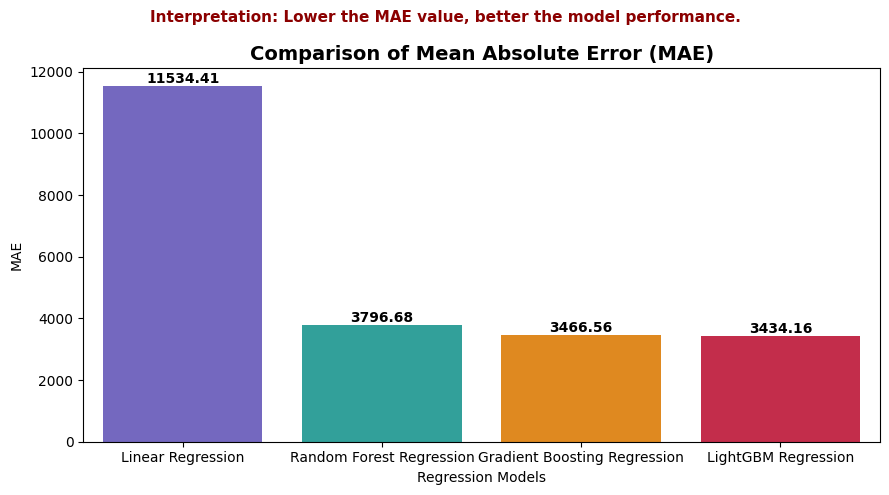

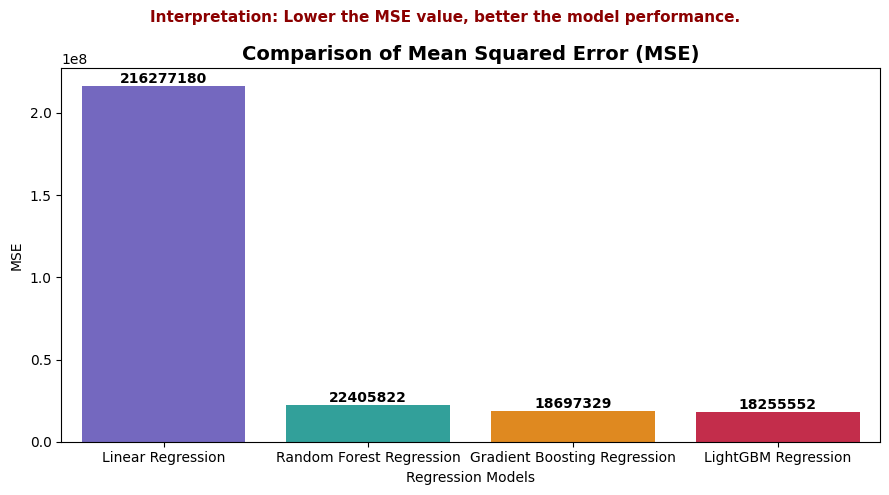

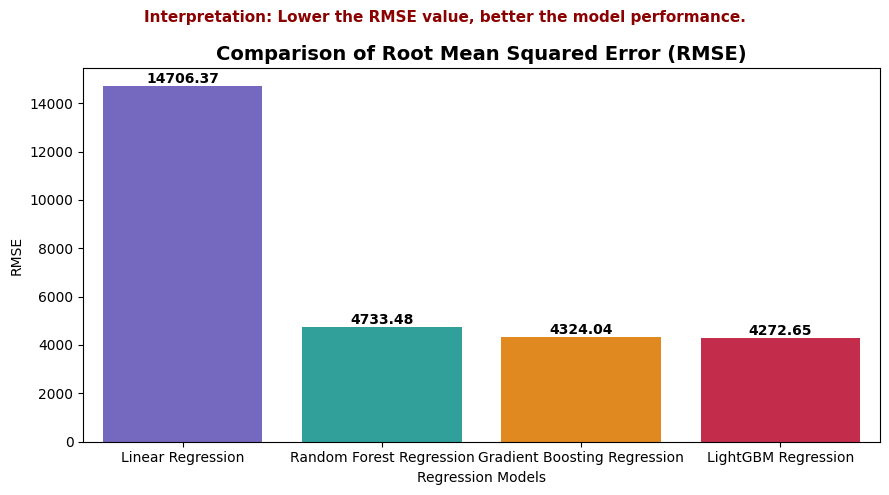

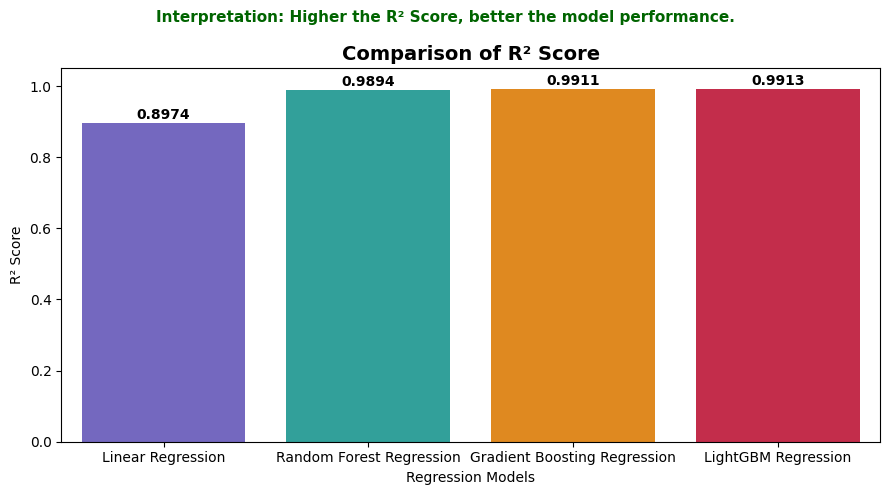

In [ ]:
# I created a comparison DataFrame for the selected regression models.
comparison_df = pd.DataFrame([
    def_lr_metric,
    def_rf_metric,
    def_gb_metric,
    def_lgbm_metric
])

# I rounded the evaluation metrics for better readability.
comparison_df = comparison_df.round({
    "MAE": 2,
    "MSE": 2,
    "RMSE": 2,
    "R2 Score": 4
})

# I defined the colours for the regression models.
model_colours = ["#6A5ACD", "#20B2AA", "#FF8C00", "#DC143C"]


# Mean Absolute Error (MAE)


plt.figure(figsize=(9,5))

plt.suptitle(
    "Interpretation: Lower the MAE value, better the model performance.",
    fontsize=11,
    fontweight="bold",
    color="darkred"
)

sns.barplot(
    data=comparison_df,
    x="Model",
    y="MAE",
    hue="Model",
    palette=model_colours,
    legend=False
)

plt.title("Comparison of Mean Absolute Error (MAE)", fontsize=14, fontweight="bold")
plt.xlabel("Regression Models")
plt.ylabel("MAE")

for index, value in enumerate(comparison_df["MAE"]):
    plt.text(index, value, f"{value:.2f}",
             ha="center",
             va="bottom",
             fontsize=10,
             fontweight="bold")

plt.tight_layout()
plt.show()


# Mean Squared Error (MSE)

plt.figure(figsize=(9,5))

plt.suptitle(
    "Interpretation: Lower the MSE value, better the model performance.",
    fontsize=11,
    fontweight="bold",
    color="darkred"
)

sns.barplot(
    data=comparison_df,
    x="Model",
    y="MSE",
    hue="Model",
    palette=model_colours,
    legend=False
)

plt.title("Comparison of Mean Squared Error (MSE)", fontsize=14, fontweight="bold")
plt.xlabel("Regression Models")
plt.ylabel("MSE")

for index, value in enumerate(comparison_df["MSE"]):
    plt.text(index, value, f"{value:.0f}",
             ha="center",
             va="bottom",
             fontsize=10,
             fontweight="bold")

plt.tight_layout()
plt.show()


# Root Mean Squared Error (RMSE)


plt.figure(figsize=(9,5))

plt.suptitle(
    "Interpretation: Lower the RMSE value, better the model performance.",
    fontsize=11,
    fontweight="bold",
    color="darkred"
)

sns.barplot(
    data=comparison_df,
    x="Model",
    y="RMSE",
    hue="Model",
    palette=model_colours,
    legend=False
)

plt.title("Comparison of Root Mean Squared Error (RMSE)", fontsize=14, fontweight="bold")
plt.xlabel("Regression Models")
plt.ylabel("RMSE")

for index, value in enumerate(comparison_df["RMSE"]):
    plt.text(index, value, f"{value:.2f}",
             ha="center",
             va="bottom",
             fontsize=10,
             fontweight="bold")

plt.tight_layout()
plt.show()

# R² Score


plt.figure(figsize=(9,5))

plt.suptitle(
    "Interpretation: Higher the R² Score, better the model performance.",
    fontsize=11,
    fontweight="bold",
    color="darkgreen"
)

sns.barplot(
    data=comparison_df,
    x="Model",
    y="R2 Score",
    hue="Model",
    palette=model_colours,
    legend=False
)

plt.title("Comparison of R² Score", fontsize=14, fontweight="bold")
plt.xlabel("Regression Models")
plt.ylabel("R² Score")

for index, value in enumerate(comparison_df["R2 Score"]):
    plt.text(index, value + 0.003, f"{value:.4f}",
             ha="center",
             va="bottom",
             fontsize=10,
             fontweight="bold")

plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

# Comparative Analysis of R² Score for all Default Models

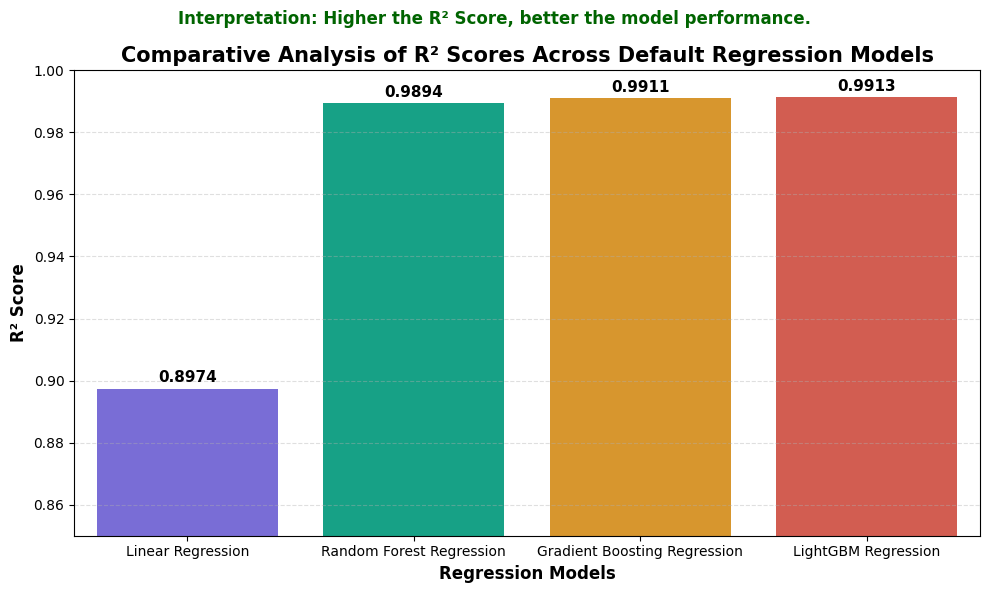

In [ ]:
# I created the comparison DataFrame.
comparison_df = pd.DataFrame([
    def_lr_metric,
    def_rf_metric,
    def_gb_metric,
    def_lgbm_metric
])

# I created the R² Score comparison graph.
plt.figure(figsize=(10,6))

plt.suptitle(
    "Interpretation: Higher the R² Score, better the model performance.",
    fontsize=12,
    fontweight="bold",
    color="darkgreen"
)

colours = ["#6C5CE7", "#00B894", "#F39C12", "#E74C3C"]

ax = sns.barplot(
    data=comparison_df,
    x="Model",
    y="R2 Score",
    hue="Model",
    palette=colours,
    legend=False
)

plt.title(
    "Comparative Analysis of R² Scores Across Default Regression Models",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Regression Models", fontsize=12, fontweight="bold")
plt.ylabel("R² Score", fontsize=12, fontweight="bold")

plt.ylim(0.85, 1.00)

# I displayed the R² Score above each bar.
for i, value in enumerate(comparison_df["R2 Score"]):
    plt.text(
        i,
        value + 0.002,
        f"{value:.4f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# I added grid lines for better readability.
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

# Overfitting Analysis of Regression Models

In [ ]:
# I created a list containing all trained regression models.
models = [
    ("Linear Regression", linear_regression, X_train_scaled, X_test_scaled),
    ("Random Forest Regression", random_forest, X_train, X_test),
    ("Gradient Boosting Regression", gradient_boosting, X_train, X_test),
    ("LightGBM Regression", lightgbm_regressor, X_train, X_test)
]

# I created an empty list to store the overfitting analysis.
overfitting_results = []

# I calculated the training and testing R² Scores for each model.
for model_name, model, Xtr, Xte in models:

    train_r2 = model.score(Xtr, y_train)
    test_r2 = model.score(Xte, y_test)

    difference = abs(train_r2 - test_r2)

    if difference < 0.01:
        conclusion = "No Significant Overfitting"
    elif difference < 0.03:
        conclusion = "Slight Overfitting"
    else:
        conclusion = "Potential Overfitting"

    overfitting_results.append({
        "Model": model_name,
        "Training R² Score": round(train_r2, 4),
        "Testing R² Score": round(test_r2, 4),
        "Difference": round(difference, 4),
        "Conclusion": conclusion
    })

# I converted the results into a DataFrame.
overfitting_df = pd.DataFrame(overfitting_results)

# I displayed the overfitting analysis.
print("Overfitting Analysis of Regression Models")


display(overfitting_df)

Overfitting Analysis of Regression Models


,Model,Training R² Score,Testing R² Score,Difference,Conclusion
0,Linear Regression,0.8982,0.8974,0.0008,No Significant Overfitting
1,Random Forest Regression,0.9937,0.9894,0.0043,No Significant Overfitting
2,Gradient Boosting Regression,0.9910,0.9911,0.0001,No Significant Overfitting
3,LightGBM Regression,0.9921,0.9913,0.0007,No Significant Overfitting


# Hyper Parameter Tuning

# 1. Linear Regressor

In [ ]:

# I imported the required libraries.
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression

# I defined the hyperparameter search space.
param_grid_lr = {
    "fit_intercept": [True, False],
    "positive": [True, False],
    "copy_X": [True, False]
}

# I created an instance of the Linear Regression model.
lr_model = LinearRegression()

# I performed Grid Search with 5-fold cross-validation.
grid_lr = GridSearchCV(
    estimator=lr_model,
    param_grid=param_grid_lr,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# I trained the Grid Search model using the scaled training dataset.
grid_lr.fit(X_train_scaled, y_train)

# I obtained the best Linear Regression model.
best_lr = grid_lr.best_estimator_

# I generated predictions using the optimised model.
y_pred_tuned_lr = best_lr.predict(X_test_scaled)

# I calculated the evaluation metrics.
mae = mean_absolute_error(y_test, y_pred_tuned_lr)
mse = mean_squared_error(y_test, y_pred_tuned_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_tuned_lr)

# I stored the evaluation metrics for later comparison.
tun_lr_metric = {
    "Model": "Linear Regression (GridSearchCV)",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2 Score": r2
}

# I displayed the best hyperparameters.
print("Best Hyperparameters:")
print(grid_lr.best_params_)

# I displayed the best cross-validation score.
print("\nBest Cross-Validation R² Score:")
print(round(grid_lr.best_score_, 4))

# I displayed the evaluation results.
print("\nOptimised Linear Regression Performance")

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Best Hyperparameters:
{'copy_X': True, 'fit_intercept': True, 'positive': False}

Best Cross-Validation R² Score:
0.898

Optimised Linear Regression Performance
Mean Absolute Error (MAE): 11534.41
Mean Squared Error (MSE): 216277179.76
Root Mean Squared Error (RMSE): 14706.37
R² Score: 0.8974


# 2. Random Forest Regressor

In [ ]:
# I imported the required libraries.
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# I defined the hyperparameter search space.
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10]
}

# I created an instance of the Random Forest Regression model.
rf_model = RandomForestRegressor(random_state=42)

# I performed Grid Search with 5-fold cross-validation.
grid_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# I trained the Grid Search model.
grid_rf.fit(X_train, y_train)

# I obtained the best Random Forest Regression model.
best_rf = grid_rf.best_estimator_

# I generated predictions using the optimised model.
y_pred_tuned_rf = best_rf.predict(X_test)

# I calculated the evaluation metrics.
mae = mean_absolute_error(y_test, y_pred_tuned_rf)
mse = mean_squared_error(y_test, y_pred_tuned_rf)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_tuned_rf)

# I stored the evaluation metrics for later comparison.
tun_rf_metric = {
    "Model": "Random Forest Regression (GridSearchCV)",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2 Score": r2
}

# I displayed the best hyperparameters.
print("Best Hyperparameters:")
print(grid_rf.best_params_)

# I displayed the best cross-validation score.
print("\nBest Cross-Validation R² Score:")
print(round(grid_rf.best_score_, 4))

# I displayed the evaluation results.
print("\nOptimised Random Forest Regression Performance")

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Best Hyperparameters:
{'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 300}

Best Cross-Validation R² Score:
0.9905

Optimised Random Forest Regression Performance
Mean Absolute Error (MAE): 3508.72
Mean Squared Error (MSE): 19044592.98
Root Mean Squared Error (RMSE): 4364.01
R² Score: 0.9910


# 3. Gradient Boosting Regressor

In [ ]:
# I imported the required libraries.
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

# I defined the hyperparameter search space.
param_grid_gb = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7]
}

# I created an instance of the Gradient Boosting Regression model.
gb_model = GradientBoostingRegressor(random_state=42)

# I performed Grid Search with 5-fold cross-validation.
grid_gb = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid_gb,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# I trained the Grid Search model.
grid_gb.fit(X_train, y_train)

# I obtained the best Gradient Boosting Regression model.
best_gb = grid_gb.best_estimator_

# I generated predictions using the optimised model.
y_pred_tuned_gb = best_gb.predict(X_test)

# I calculated the evaluation metrics.
mae = mean_absolute_error(y_test, y_pred_tuned_gb)
mse = mean_squared_error(y_test, y_pred_tuned_gb)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_tuned_gb)

# I stored the evaluation metrics for later comparison.
tun_gb_metric = {
    "Model": "Gradient Boosting Regression (GridSearchCV)",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2 Score": r2
}

# I displayed the best hyperparameters.
print("Best Hyperparameters:")
print(grid_gb.best_params_)

# I displayed the best cross-validation score.
print("\nBest Cross-Validation R² Score:")
print(round(grid_gb.best_score_, 4))

# I displayed the evaluation results.
print("\nOptimised Gradient Boosting Regression Performance")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Best Hyperparameters:
{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}

Best Cross-Validation R² Score:
0.9911

Optimised Gradient Boosting Regression Performance
Mean Absolute Error (MAE): 3405.47
Mean Squared Error (MSE): 18057669.96
Root Mean Squared Error (RMSE): 4249.43
R² Score: 0.9914


# 4. Optimized LightGBM Regressor

In [ ]:
# I imported the required libraries.
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV

# I defined the hyperparameter search space.
param_grid_lgbm = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [31, 50, 70]
}

# I created an instance of the LightGBM Regression model.
lgbm_model = LGBMRegressor(
    random_state=42,
    verbose=-1
)

# I performed Grid Search with 5-fold cross-validation.
grid_lgbm = GridSearchCV(
    estimator=lgbm_model,
    param_grid=param_grid_lgbm,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# I trained the Grid Search model.
grid_lgbm.fit(X_train, y_train)

# I obtained the best LightGBM Regression model.
best_lgbm = grid_lgbm.best_estimator_

# I generated predictions using the optimised model.
y_pred_tuned_lgbm = best_lgbm.predict(X_test)

# I calculated the evaluation metrics.
mae = mean_absolute_error(y_test, y_pred_tuned_lgbm)
mse = mean_squared_error(y_test, y_pred_tuned_lgbm)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_tuned_lgbm)

# I stored the evaluation metrics for later comparison.
tun_lgbm_metric = {
    "Model": "LightGBM Regression (GridSearchCV)",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2 Score": r2
}

# I displayed the best hyperparameters.
print("Best Hyperparameters:")
print(grid_lgbm.best_params_)

# I displayed the best cross-validation score.
print("\nBest Cross-Validation R² Score:")
print(round(grid_lgbm.best_score_, 4))

# I displayed the evaluation results.
print("\nOptimised LightGBM Regression Performance")

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Best Hyperparameters:
{'learning_rate': 0.05, 'n_estimators': 100, 'num_leaves': 31}

Best Cross-Validation R² Score:
0.9911

Optimised LightGBM Regression Performance
Mean Absolute Error (MAE): 3416.64
Mean Squared Error (MSE): 18055475.28
Root Mean Squared Error (RMSE): 4249.17
R² Score: 0.9914


# Comparative Performance of Optimised Regression Models

In [ ]:
# I updated the model names for presentation.
tun_lr_metric["Model"] = "Linear Regression"
tun_rf_metric["Model"] = "Random Forest Regression"
tun_gb_metric["Model"] = "Gradient Boosting Regression"
tun_lgbm_metric["Model"] = "LightGBM Regression"

# I combined the evaluation metrics of the optimised regression models.
optimised_comparison_df = pd.DataFrame([
    tun_lr_metric,
    tun_rf_metric,
    tun_gb_metric,
    tun_lgbm_metric
])

# I rounded the evaluation metrics for better readability.
optimised_comparison_df["MAE"] = optimised_comparison_df["MAE"].round(2)
optimised_comparison_df["MSE"] = optimised_comparison_df["MSE"].round(2)
optimised_comparison_df["RMSE"] = optimised_comparison_df["RMSE"].round(2)
optimised_comparison_df["R2 Score"] = optimised_comparison_df["R2 Score"].round(4)



display(
    optimised_comparison_df.style
    .hide(axis="index")
    .set_caption("Table: Comparative Performance of Optimised Regression Models")
    .set_properties(**{
        "text-align": "center",
        "font-size": "12pt",
        "border": "1px solid black"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#2C3E50"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid black")
            ]
        },
        {
            "selector": "caption",
            "props": [
                ("font-size", "14pt"),
                ("font-weight", "bold"),
                ("color", "#2C3E50")
            ]
        }
    ])
    .apply(
        lambda row: [
            "background-color: #E8DAEF" if row.name == 0 else   # Linear Regression
            "background-color: #D6EAF8" if row.name == 1 else   # Random Forest
            "background-color: #FAD7A0" if row.name == 2 else   # Gradient Boosting
            "background-color: #D5F5E3"                         # LightGBM
            for _ in row
        ],
        axis=1
    )
)

Model,MAE,MSE,RMSE,R2 Score
Linear Regression,11534.410000,216277179.760000,14706.370000,0.897400
Random Forest Regression,3508.720000,19044592.980000,4364.010000,0.991000
Gradient Boosting Regression,3405.470000,18057669.960000,4249.430000,0.991400
LightGBM Regression,3416.640000,18055475.280000,4249.170000,0.991400


# Comparative Performance Graphs of Optimised Regression Models

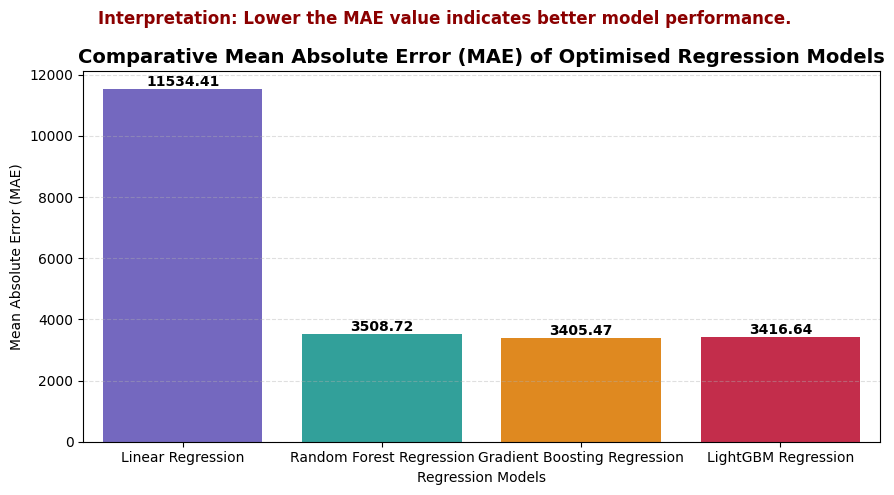

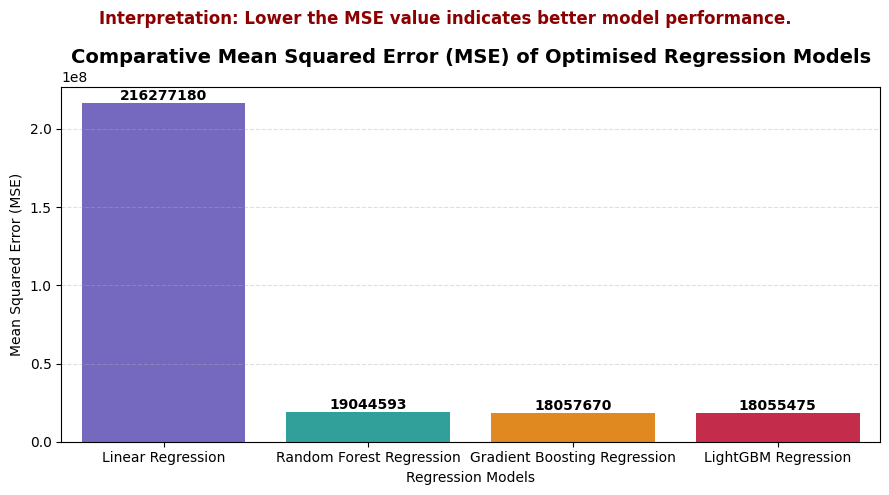

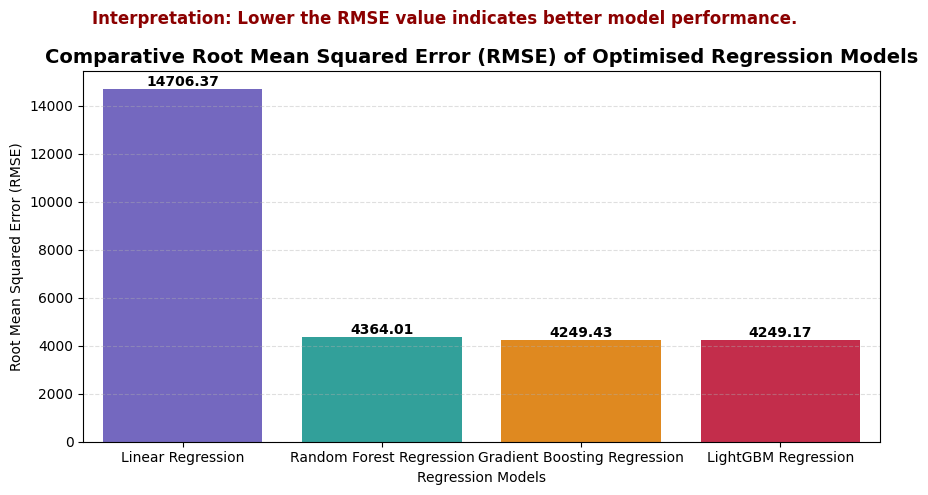

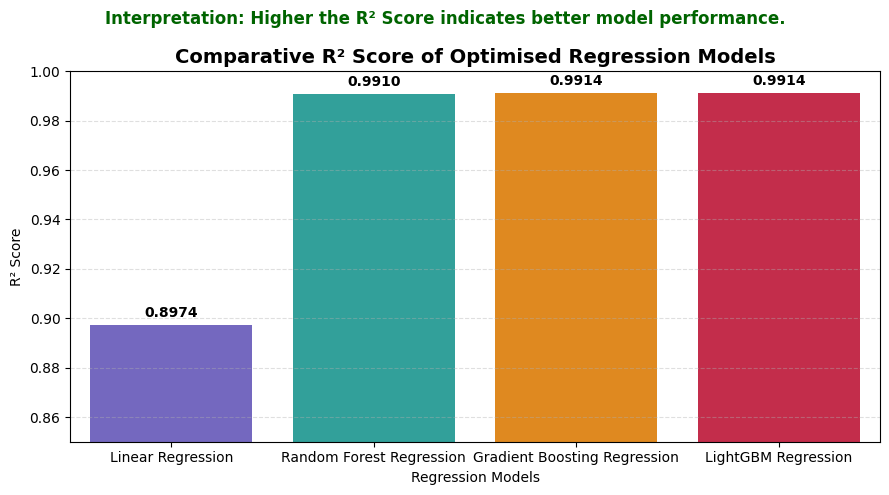

In [ ]:
# I updated the model names for presentation.
tun_lr_metric["Model"] = "Linear Regression"
tun_rf_metric["Model"] = "Random Forest Regression"
tun_gb_metric["Model"] = "Gradient Boosting Regression"
tun_lgbm_metric["Model"] = "LightGBM Regression"

# I created a comparison DataFrame for the optimised regression models.
comparison_df = pd.DataFrame([
    tun_lr_metric,
    tun_rf_metric,
    tun_gb_metric,
    tun_lgbm_metric
])

# I rounded the evaluation metrics for better readability.
comparison_df = comparison_df.round({
    "MAE": 2,
    "MSE": 2,
    "RMSE": 2,
    "R2 Score": 4
})

# I defined the colours for the regression models.
model_colours = ["#6A5ACD", "#20B2AA", "#FF8C00", "#DC143C"]


# Mean Absolute Error (MAE)


plt.figure(figsize=(9,5))

plt.suptitle(
    "Interpretation: Lower the MAE value indicates better model performance.",
    fontsize=12,
    fontweight="bold",
    color="darkred"
)

sns.barplot(
    data=comparison_df,
    x="Model",
    y="MAE",
    hue="Model",
    palette=model_colours,
    legend=False
)

plt.title(
    "Comparative Mean Absolute Error (MAE) of Optimised Regression Models",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Regression Models")
plt.ylabel("Mean Absolute Error (MAE)")

for index, value in enumerate(comparison_df["MAE"]):
    plt.text(index, value, f"{value:.2f}",
             ha="center",
             va="bottom",
             fontsize=10,
             fontweight="bold")

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


# Mean Squared Error (MSE)


plt.figure(figsize=(9,5))

plt.suptitle(
    "Interpretation: Lower the MSE value indicates better model performance.",
    fontsize=12,
    fontweight="bold",
    color="darkred"
)

sns.barplot(
    data=comparison_df,
    x="Model",
    y="MSE",
    hue="Model",
    palette=model_colours,
    legend=False
)

plt.title(
    "Comparative Mean Squared Error (MSE) of Optimised Regression Models",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Regression Models")
plt.ylabel("Mean Squared Error (MSE)")

for index, value in enumerate(comparison_df["MSE"]):
    plt.text(index, value, f"{value:.0f}",
             ha="center",
             va="bottom",
             fontsize=10,
             fontweight="bold")

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


# Root Mean Squared Error (RMSE)


plt.figure(figsize=(9,5))

plt.suptitle(
    "Interpretation: Lower the RMSE value indicates better model performance.",
    fontsize=12,
    fontweight="bold",
    color="darkred"
)

sns.barplot(
    data=comparison_df,
    x="Model",
    y="RMSE",
    hue="Model",
    palette=model_colours,
    legend=False
)

plt.title(
    "Comparative Root Mean Squared Error (RMSE) of Optimised Regression Models",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Regression Models")
plt.ylabel("Root Mean Squared Error (RMSE)")

for index, value in enumerate(comparison_df["RMSE"]):
    plt.text(index, value, f"{value:.2f}",
             ha="center",
             va="bottom",
             fontsize=10,
             fontweight="bold")

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


# R² Score


plt.figure(figsize=(9,5))

plt.suptitle(
    "Interpretation: Higher the R² Score indicates better model performance.",
    fontsize=12,
    fontweight="bold",
    color="darkgreen"
)

sns.barplot(
    data=comparison_df,
    x="Model",
    y="R2 Score",
    hue="Model",
    palette=model_colours,
    legend=False
)

plt.title(
    "Comparative R² Score of Optimised Regression Models",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Regression Models")
plt.ylabel("R² Score")

for index, value in enumerate(comparison_df["R2 Score"]):
    plt.text(index,
             value + 0.002,
             f"{value:.4f}",
             ha="center",
             va="bottom",
             fontsize=10,
             fontweight="bold")

plt.ylim(0.85, 1.00)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Comparative R² Score of Optimised Regression Models

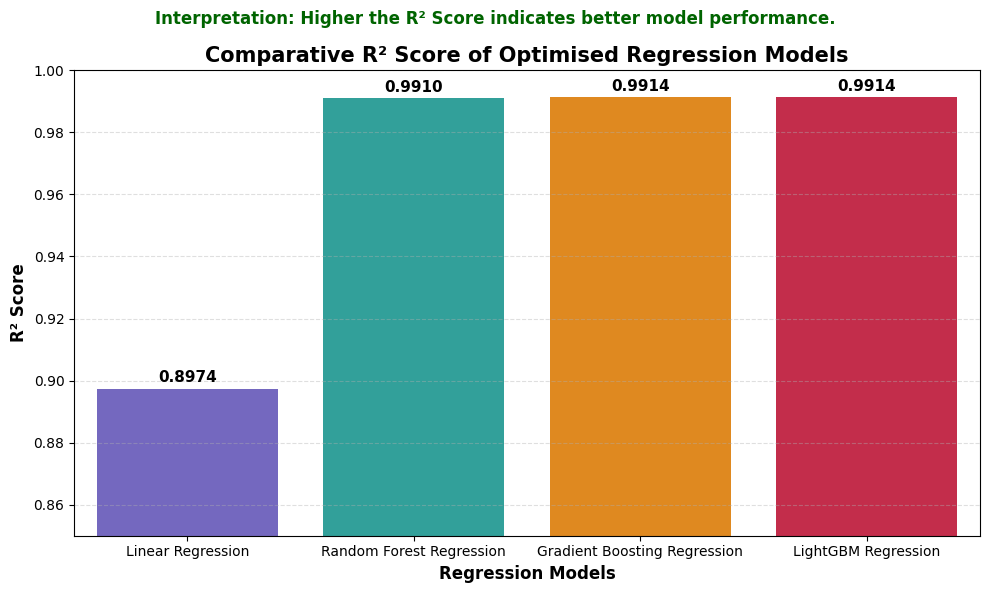

In [ ]:
# I updated the model names for presentation.
tun_lr_metric["Model"] = "Linear Regression"
tun_rf_metric["Model"] = "Random Forest Regression"
tun_gb_metric["Model"] = "Gradient Boosting Regression"
tun_lgbm_metric["Model"] = "LightGBM Regression"

# I created the comparison DataFrame.
comparison_df = pd.DataFrame([
    tun_lr_metric,
    tun_rf_metric,
    tun_gb_metric,
    tun_lgbm_metric
])

# I created the R² Score comparison graph.
plt.figure(figsize=(10,6))

plt.suptitle(
    "Interpretation: Higher the R² Score indicates better model performance.",
    fontsize=12,
    fontweight="bold",
    color="darkgreen"
)

colours = ["#6A5ACD", "#20B2AA", "#FF8C00", "#DC143C"]

sns.barplot(
    data=comparison_df,
    x="Model",
    y="R2 Score",
    hue="Model",
    palette=colours,
    legend=False
)

plt.title(
    "Comparative R² Score of Optimised Regression Models",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Regression Models", fontsize=12, fontweight="bold")
plt.ylabel("R² Score", fontsize=12, fontweight="bold")

plt.ylim(0.85, 1.00)

# I displayed the R² Score above each bar.
for i, value in enumerate(comparison_df["R2 Score"]):
    plt.text(
        i,
        value + 0.002,
        f"{value:.4f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

# Comparative Performance of Baseline and Optimised Regression Models

In [ ]:
# I updated the model names.
def_lr_metric["Model"] = "Linear Regression"
def_rf_metric["Model"] = "Random Forest Regression"
def_gb_metric["Model"] = "Gradient Boosting Regression"
def_lgbm_metric["Model"] = "LightGBM Regression"

tun_lr_metric["Model"] = "Linear Regression"
tun_rf_metric["Model"] = "Random Forest Regression"
tun_gb_metric["Model"] = "Gradient Boosting Regression"
tun_lgbm_metric["Model"] = "LightGBM Regression"

# I created the baseline DataFrame.
baseline_df = pd.DataFrame([
    def_lr_metric,
    def_rf_metric,
    def_gb_metric,
    def_lgbm_metric
])

baseline_df["Type"] = "Baseline"

# I created the optimised DataFrame.
optimised_df = pd.DataFrame([
    tun_lr_metric,
    tun_rf_metric,
    tun_gb_metric,
    tun_lgbm_metric
])

optimised_df["Type"] = "Optimised"

# I combined the baseline and optimised results.
comparison_df = pd.concat(
    [baseline_df, optimised_df],
    ignore_index=True
)

# I rounded the evaluation metrics.
comparison_df = comparison_df.round({
    "MAE": 2,
    "MSE": 2,
    "RMSE": 2,
    "R2 Score": 4
})

# I arranged the columns.
comparison_df = comparison_df[
    [
        "Type",
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score"
    ]
]


display(
    comparison_df.style
    .hide(axis="index")
    .set_caption("Table: Comparative Performance of Default and Optimised Regression Models")
    .set_properties(**{
        "text-align":"center",
        "font-size":"12pt",
        "border":"1px solid black"
    })
    .set_table_styles([
        {
            "selector":"th",
            "props":[
                ("background-color","#2C3E50"),
                ("color","white"),
                ("font-weight","bold"),
                ("text-align","center"),
                ("border","1px solid black")
            ]
        },
        {
            "selector":"caption",
            "props":[
                ("font-size","14pt"),
                ("font-weight","bold"),
                ("color","#2C3E50")
            ]
        }
    ])
    .apply(
        lambda row: [
            # Baseline Models
            "background-color:#E8DAEF" if row["Type"]=="Baseline" and row["Model"]=="Linear Regression" else
            "background-color:#D6EAF8" if row["Type"]=="Baseline" and row["Model"]=="Random Forest Regression" else
            "background-color:#FAD7A0" if row["Type"]=="Baseline" and row["Model"]=="Gradient Boosting Regression" else
            "background-color:#D5F5E3" if row["Type"]=="Baseline" and row["Model"]=="LightGBM Regression" else

            # Optimised Models
            "background-color:#D2B4DE" if row["Model"]=="Linear Regression" else
            "background-color:#AED6F1" if row["Model"]=="Random Forest Regression" else
            "background-color:#F8C471" if row["Model"]=="Gradient Boosting Regression" else
            "background-color:#A9DFBF"

            for _ in row
        ],
        axis=1
    )
)

Type,Model,MAE,MSE,RMSE,R2 Score
Baseline,Linear Regression,11534.410000,216277179.760000,14706.370000,0.897400
Baseline,Random Forest Regression,3796.680000,22405821.880000,4733.480000,0.989400
Baseline,Gradient Boosting Regression,3466.560000,18697329.330000,4324.040000,0.991100
Baseline,LightGBM Regression,3434.160000,18255551.540000,4272.650000,0.991300
Optimised,Linear Regression,11534.410000,216277179.760000,14706.370000,0.897400
Optimised,Random Forest Regression,3508.720000,19044592.980000,4364.010000,0.991000
Optimised,Gradient Boosting Regression,3405.470000,18057669.960000,4249.430000,0.991400
Optimised,LightGBM Regression,3416.640000,18055475.280000,4249.170000,0.991400


# Comparative Performance Graphs of Baseline and Optimised Regression Models

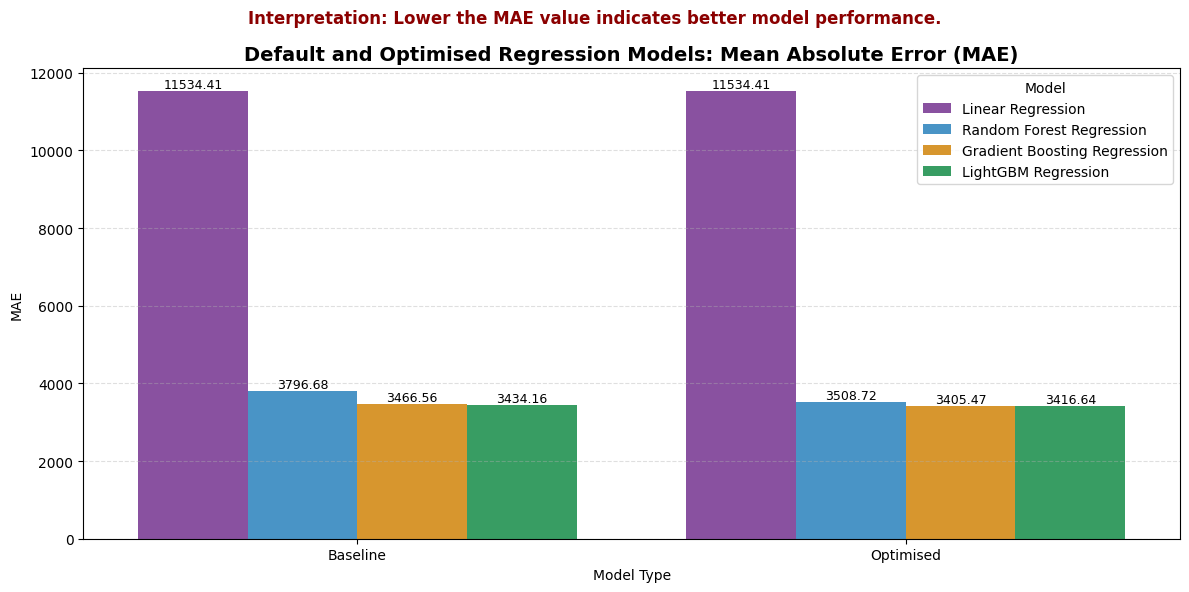

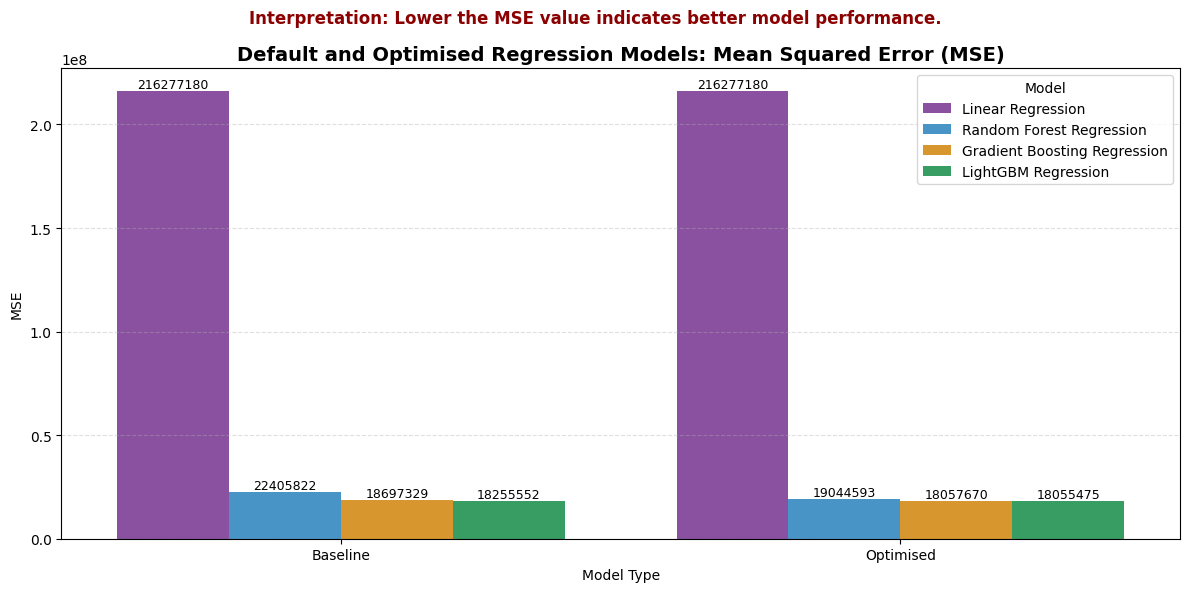

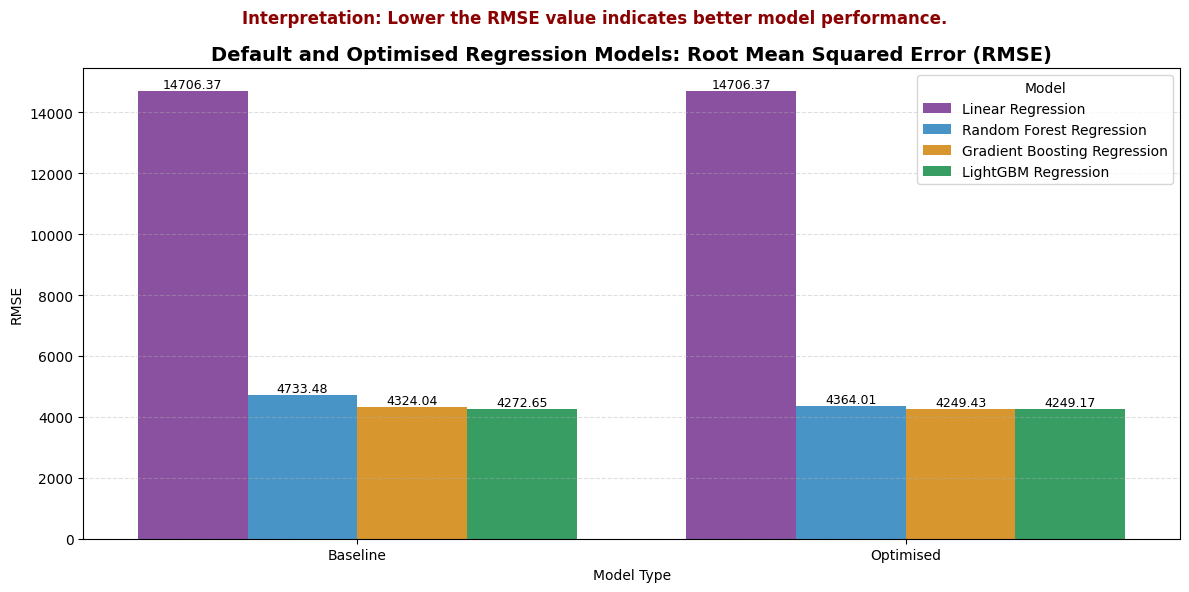

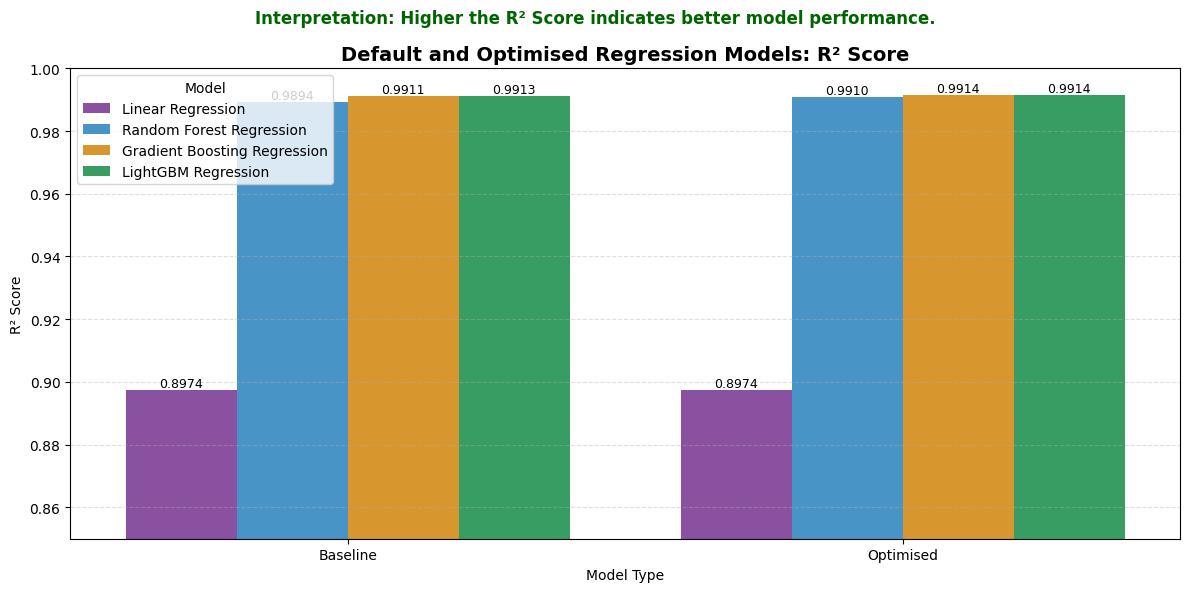

In [ ]:
# I updated the model names.
def_lr_metric["Model"] = "Linear Regression"
def_rf_metric["Model"] = "Random Forest Regression"
def_gb_metric["Model"] = "Gradient Boosting Regression"
def_lgbm_metric["Model"] = "LightGBM Regression"

tun_lr_metric["Model"] = "Linear Regression"
tun_rf_metric["Model"] = "Random Forest Regression"
tun_gb_metric["Model"] = "Gradient Boosting Regression"
tun_lgbm_metric["Model"] = "LightGBM Regression"

# I created the baseline DataFrame.
baseline_df = pd.DataFrame([
    def_lr_metric,
    def_rf_metric,
    def_gb_metric,
    def_lgbm_metric
])
baseline_df["Type"] = "Baseline"

# I created the optimised DataFrame.
optimised_df = pd.DataFrame([
    tun_lr_metric,
    tun_rf_metric,
    tun_gb_metric,
    tun_lgbm_metric
])
optimised_df["Type"] = "Optimised"

# I combined both DataFrames.
comparison_df = pd.concat([baseline_df, optimised_df], ignore_index=True)

# I rounded the evaluation metrics.
comparison_df = comparison_df.round({
    "MAE": 2,
    "MSE": 2,
    "RMSE": 2,
    "R2 Score": 4
})

# I defined colours for each regression model.
model_palette = {
    "Linear Regression": "#8E44AD",
    "Random Forest Regression": "#3498DB",
    "Gradient Boosting Regression": "#F39C12",
    "LightGBM Regression": "#27AE60"
}


# Mean Absolute Error (MAE)


plt.figure(figsize=(12,6))

plt.suptitle(
    "Interpretation: Lower the MAE value indicates better model performance.",
    fontsize=12,
    fontweight="bold",
    color="darkred"
)

ax = sns.barplot(
    data=comparison_df,
    x="Type",
    y="MAE",
    hue="Model",
    palette=model_palette
)

plt.title(
    "Default and Optimised Regression Models: Mean Absolute Error (MAE)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Model Type")
plt.ylabel("MAE")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=9)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


# Mean Squared Error (MSE)


plt.figure(figsize=(12,6))

plt.suptitle(
    "Interpretation: Lower the MSE value indicates better model performance.",
    fontsize=12,
    fontweight="bold",
    color="darkred"
)

ax = sns.barplot(
    data=comparison_df,
    x="Type",
    y="MSE",
    hue="Model",
    palette=model_palette
)

plt.title(
    "Default and Optimised Regression Models: Mean Squared Error (MSE)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Model Type")
plt.ylabel("MSE")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=9)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


# Root Mean Squared Error (RMSE)

plt.figure(figsize=(12,6))

plt.suptitle(
    "Interpretation: Lower the RMSE value indicates better model performance.",
    fontsize=12,
    fontweight="bold",
    color="darkred"
)

ax = sns.barplot(
    data=comparison_df,
    x="Type",
    y="RMSE",
    hue="Model",
    palette=model_palette
)

plt.title(
    "Default and Optimised Regression Models: Root Mean Squared Error (RMSE)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Model Type")
plt.ylabel("RMSE")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=9)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


# R² Score


plt.figure(figsize=(12,6))

plt.suptitle(
    "Interpretation: Higher the R² Score indicates better model performance.",
    fontsize=12,
    fontweight="bold",
    color="darkgreen"
)

ax = sns.barplot(
    data=comparison_df,
    x="Type",
    y="R2 Score",
    hue="Model",
    palette=model_palette
)

plt.title(
    "Default and Optimised Regression Models: R² Score",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Model Type")
plt.ylabel("R² Score")

plt.ylim(0.85, 1.00)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", fontsize=9)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# Comparative R² Score of Baseline and Optimised Regression Models

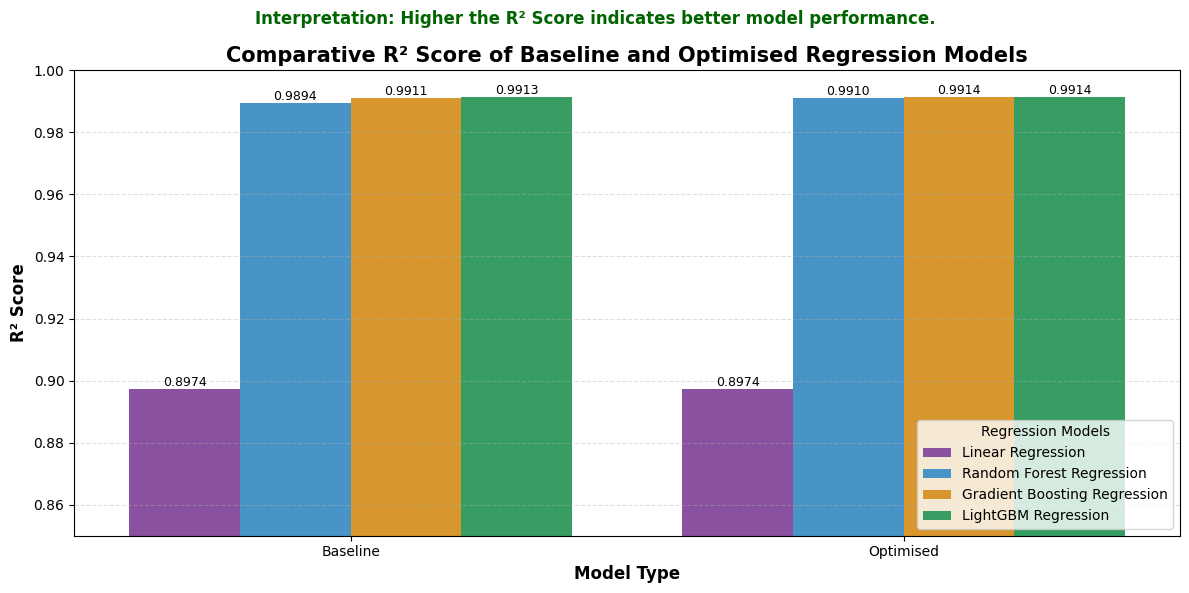

In [ ]:
# I updated the model names.
def_lr_metric["Model"] = "Linear Regression"
def_rf_metric["Model"] = "Random Forest Regression"
def_gb_metric["Model"] = "Gradient Boosting Regression"
def_lgbm_metric["Model"] = "LightGBM Regression"

tun_lr_metric["Model"] = "Linear Regression"
tun_rf_metric["Model"] = "Random Forest Regression"
tun_gb_metric["Model"] = "Gradient Boosting Regression"
tun_lgbm_metric["Model"] = "LightGBM Regression"

# I created the baseline DataFrame.
baseline_df = pd.DataFrame([
    def_lr_metric,
    def_rf_metric,
    def_gb_metric,
    def_lgbm_metric
])

baseline_df["Type"] = "Baseline"

# I created the optimised DataFrame.
optimised_df = pd.DataFrame([
    tun_lr_metric,
    tun_rf_metric,
    tun_gb_metric,
    tun_lgbm_metric
])

optimised_df["Type"] = "Optimised"

# I combined the results.
comparison_df = pd.concat(
    [baseline_df, optimised_df],
    ignore_index=True
)

# I defined colours for each regression model.
model_palette = {
    "Linear Regression": "#8E44AD",
    "Random Forest Regression": "#3498DB",
    "Gradient Boosting Regression": "#F39C12",
    "LightGBM Regression": "#27AE60"
}


# R² Score Comparison


plt.figure(figsize=(12,6))

plt.suptitle(
    "Interpretation: Higher the R² Score indicates better model performance.",
    fontsize=12,
    fontweight="bold",
    color="darkgreen"
)

ax = sns.barplot(
    data=comparison_df,
    x="Type",
    y="R2 Score",
    hue="Model",
    palette=model_palette
)

plt.title(
    "Comparative R² Score of Baseline and Optimised Regression Models",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Model Type", fontsize=12, fontweight="bold")
plt.ylabel("R² Score", fontsize=12, fontweight="bold")

plt.ylim(0.85, 1.00)

# I displayed the R² Score above each bar.
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", fontsize=9)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend(
    title="Regression Models",
    loc="lower right"
)

plt.tight_layout()

plt.show()

# Overall Best Performing Regression Model

In [ ]:
# I updated the model names.
def_lr_metric["Model"] = "Linear Regression"
def_rf_metric["Model"] = "Random Forest Regression"
def_gb_metric["Model"] = "Gradient Boosting Regression"
def_lgbm_metric["Model"] = "LightGBM Regression"

tun_lr_metric["Model"] = "Linear Regression"
tun_rf_metric["Model"] = "Random Forest Regression"
tun_gb_metric["Model"] = "Gradient Boosting Regression"
tun_lgbm_metric["Model"] = "LightGBM Regression"

# I created the baseline DataFrame.
baseline_df = pd.DataFrame([
    def_lr_metric,
    def_rf_metric,
    def_gb_metric,
    def_lgbm_metric
])

baseline_df["Model Type"] = "Baseline"

# I created the optimised DataFrame.
optimised_df = pd.DataFrame([
    tun_lr_metric,
    tun_rf_metric,
    tun_gb_metric,
    tun_lgbm_metric
])

optimised_df["Model Type"] = "Optimised"

# I combined all regression models.
all_models_df = pd.concat(
    [baseline_df, optimised_df],
    ignore_index=True
)

# I selected the overall best-performing model.
best_model = all_models_df.sort_values(
    by=["R2 Score", "MAE", "RMSE"],
    ascending=[False, True, True]
).iloc[0]

# I displayed the overall best-performing model.

print("Overall Best Performing Regression Model")

print(f"Model Type               : {best_model['Model Type']}")
print(f"Regression Model         : {best_model['Model']}")
print(f"Mean Absolute Error      : {best_model['MAE']:.2f}")
print(f"Mean Squared Error       : {best_model['MSE']:.2f}")
print(f"Root Mean Squared Error  : {best_model['RMSE']:.2f}")
print(f"R² Score                 : {best_model['R2 Score']:.4f}")

# I displayed the best-performing model in tabular format.
best_model_df = pd.DataFrame([best_model])

print("\n")
display(best_model_df)

Overall Best Performing Regression Model
Model Type               : Optimised
Regression Model         : LightGBM Regression
Mean Absolute Error      : 3416.64
Mean Squared Error       : 18055475.28
Root Mean Squared Error  : 4249.17
R² Score                 : 0.9914




,Model,MAE,MSE,RMSE,R2 Score,Model Type
7,LightGBM Regression,3416.637668,1.805548e+07,4249.173482,0.991433,Optimised


# Saving the Best Model

In [ ]:
# I imported the LabelEncoder class for encoding categorical attributes.
from sklearn.preprocessing import LabelEncoder

# I created a dictionary to store the LabelEncoders.
label_encoders = {}

# I identified the categorical attributes.
categorical_columns = ["Department", "Job_Title", "Education_Level", "Location"]

# I encoded the categorical attributes.
for column in categorical_columns:

    encoder = LabelEncoder()

    df[column] = encoder.fit_transform(df[column])

    label_encoders[column] = encoder

# I displayed the first five records after encoding.
print("Dataset After Label Encoding:")
print(df.head())

# I displayed the data types after encoding.
print("\nData Types After Encoding:")
print(df.dtypes)

Dataset After Label Encoding:
   Age  Department  Job_Title  Experience_Years  Education_Level  Location  \
0   24           0          1                 1                1         0   
1   56           5          2                33                1         4   
2   21           0          3                 1                0         2   
3   30           1          0                 9                0         2   
4   25           2          0                 2                1         4   

   Salary  
0   90000  
1  195000  
2   35000  
3   75000  
4   70000  

Data Types After Encoding:
Age                 int64
Department          int64
Job_Title           int64
Experience_Years    int64
Education_Level     int64
Location            int64
Salary              int64
dtype: object


In [ ]:
import joblib

# I saved the best-performing LightGBM Regression model.
joblib.dump(best_lgbm, "Salary_best_lightgbm_regression_model.pkl")

# I saved the fitted StandardScaler.
joblib.dump(feature_scaler, "Salary_feature_scaler.pkl")

# I saved the Label Encoders.
joblib.dump(label_encoders, "Salary_label_encoders.pkl")

print("Salary_best_lightgbm_regression_model.pkl saved successfully.")
print("Salary_feature_scaler.pkl saved successfully.")
print("Salary_label_encoders.pkl saved successfully.")

Salary_best_lightgbm_regression_model.pkl saved successfully.
Salary_feature_scaler.pkl saved successfully.
Salary_label_encoders.pkl saved successfully.


# SHAP Analysis for the Best Performing Optimised LightGBM Regression Model

SHAP ANALYSIS OF THE BEST PERFORMING OPTIMISED LIGHTGBM REGRESSION MODEL

SHAP Summary Plot
Interpretation: Features at the top have the greatest influence on salary prediction.


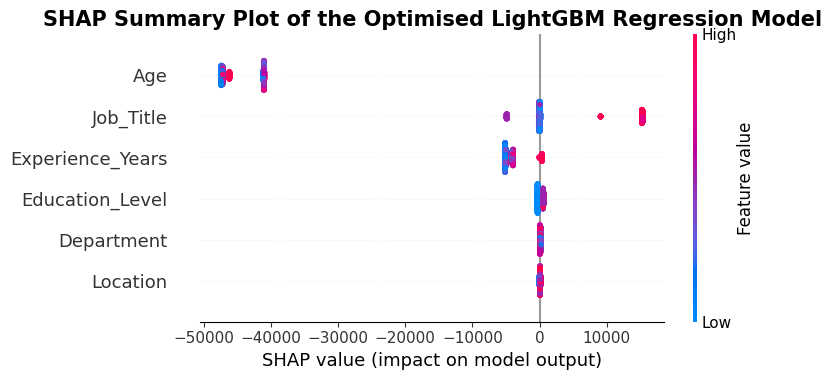


SHAP Feature Importance Plot
Interpretation: Longer bars indicate more influential features.


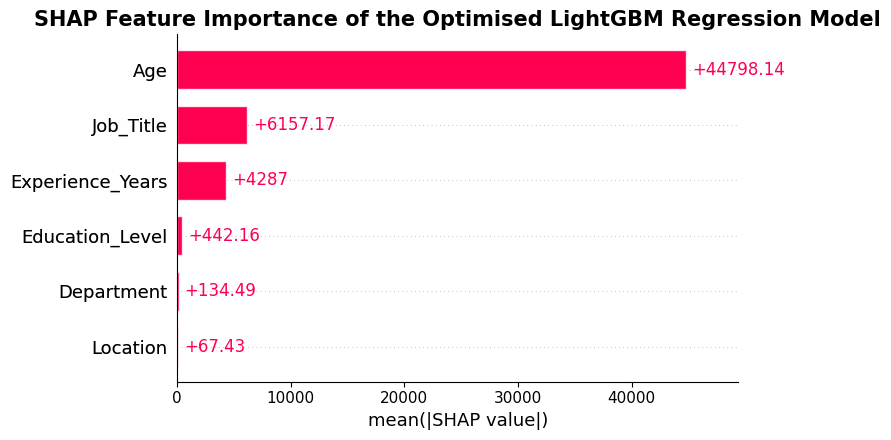


SHAP Dependence Plot
Interpretation: Demonstrates how the most important feature influences the predicted salary.


<Figure size 1000x600 with 0 Axes>

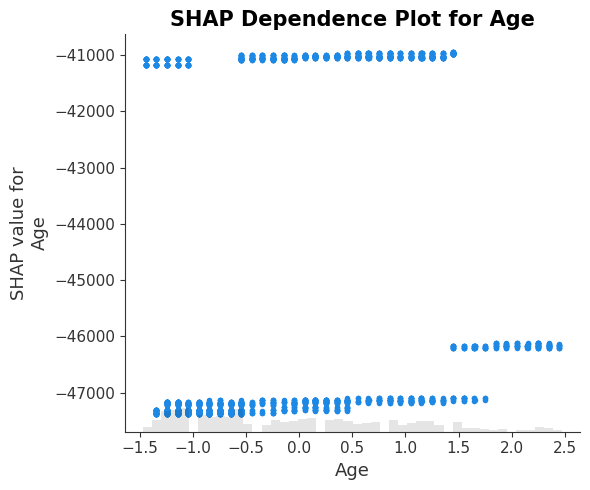


SHAP Waterfall Plot
Interpretation: Demonstrates how each feature contributes positively or negatively towards an individual salary prediction.


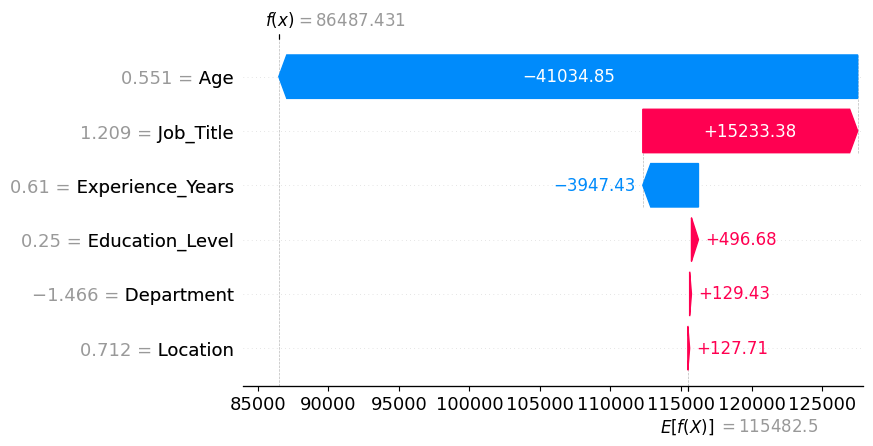

In [ ]:
# I imported the required libraries.
import shap
import pandas as pd
import matplotlib.pyplot as plt

# I converted the scaled feature matrices back into DataFrames
# to preserve the original feature names.
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

# I created the SHAP explainer.
explainer = shap.Explainer(best_lgbm)

# I calculated the SHAP values.
shap_values = explainer(X_test_scaled_df)

print("SHAP ANALYSIS OF THE BEST PERFORMING OPTIMISED LIGHTGBM REGRESSION MODEL")



# Plot 1 : SHAP Summary Plot

print("\nSHAP Summary Plot")
print("Interpretation: Features at the top have the greatest influence on salary prediction.")

plt.figure(figsize=(10,6))

shap.plots.beeswarm(
    shap_values,
    max_display=10,
    show=False
)

plt.title(
    "SHAP Summary Plot of the Optimised LightGBM Regression Model",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# Plot 2 : SHAP Feature Importance Plot


print("\nSHAP Feature Importance Plot")
print("Interpretation: Longer bars indicate more influential features.")

plt.figure(figsize=(10,6))

shap.plots.bar(
    shap_values,
    max_display=10,
    show=False
)

plt.title(
    "SHAP Feature Importance of the Optimised LightGBM Regression Model",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# Plot 3 : SHAP Dependence Plot


print("\nSHAP Dependence Plot")
print("Interpretation: Demonstrates how the most important feature influences the predicted salary.")

# Automatically identify the most important feature
importance = abs(shap_values.values).mean(axis=0)

best_feature = X_test_scaled_df.columns[
    importance.argmax()
]

plt.figure(figsize=(10,6))

shap.plots.scatter(
    shap_values[:, best_feature],
    show=False
)

plt.title(
    f"SHAP Dependence Plot for {best_feature}",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


print("\nSHAP Waterfall Plot")
print("Interpretation: Demonstrates how each feature contributes positively or negatively towards an individual salary prediction.")

shap.plots.waterfall(
    shap_values[0],
    max_display=10
)


# LIME Analysis for the Best Performing Optimised LightGBM Regression Model

LIME ANALYSIS OF THE BEST PERFORMING OPTIMISED LIGHTGBM REGRESSION MODEL

Predicted Salary:
86487.43076414295

Feature Contributions:
-0.02 < Job_Title <= 1.21                11757.0135
-0.15 < Age <= 0.75                      270.3234
-0.26 < Experience_Years <= 0.72         209.6366
-1.20 < Education_Level <= 0.25          -143.2560
0.01 < Location <= 0.71                  83.6761
Department <= -0.88                      10.7133


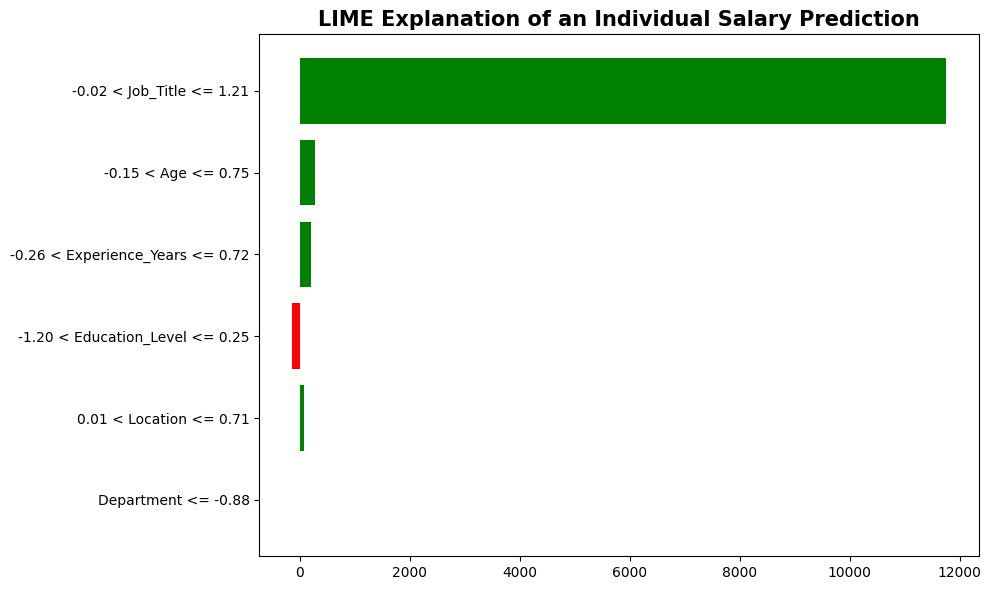

In [ ]:
# I imported the required libraries.
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import pandas as pd

# I converted the scaled datasets into DataFrames to preserve feature names.
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

# I created the LIME explainer.
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled_df.values,
    feature_names=X_train_scaled_df.columns.tolist(),
    mode="regression",
    discretize_continuous=True,
    random_state=42
)

# I selected a testing instance for explanation.
instance_index = 0

# I generated the LIME explanation.
explanation = explainer.explain_instance(
    data_row=X_test_scaled_df.iloc[instance_index].values,
    predict_fn=best_lgbm.predict,
    num_features=6
)


print("LIME ANALYSIS OF THE BEST PERFORMING OPTIMISED LIGHTGBM REGRESSION MODEL")


print("\nPredicted Salary:")
print(best_lgbm.predict(X_test_scaled_df.iloc[[instance_index]])[0])

print("\nFeature Contributions:")
for feature, weight in explanation.as_list():
    print(f"{feature:<40} {weight:.4f}")

# LIME Explanation Plot


fig = explanation.as_pyplot_figure()

fig.set_size_inches(10, 6)

plt.title(
    "LIME Explanation of an Individual Salary Prediction",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

# Human Evaluation Purpose

In [ ]:
import tkinter as tk
from tkinter import ttk, messagebox
from tkinter.scrolledtext import ScrolledText
import joblib
import pandas as pd
import os

MODEL = joblib.load("Salary_best_lightgbm_regression_model.pkl")


department_map = {
    "Engineering": 0,
    "Finance": 1,
    "HR": 2,
    "Marketing": 3,
    "Product": 4,
    "Sales": 5
}

job_title_map = {
    "Analyst": 0,
    "Engineer": 1,
    "Executive": 2,
    "Intern": 3,
    "Manager": 4
}

education_map = {
    "Bachelor": 0,
    "Master": 1,
    "PhD": 2
}

location_map = {
    "Austin": 0,
    "Chicago": 1,
    "New York": 2,
    "San Francisco": 3,
    "Seattle": 4
}


root = tk.Tk()

root.title("Employee Salary Prediction Prototype")

root.geometry("950x760")

root.configure(bg="#EAF4FC")



title = tk.Label(
    root,
    text="Employee Salary Prediction Prototype",
    bg="#1565C0",
    fg="white",
    font=("Segoe UI",20,"bold"),
    pady=10
)

title.pack(fill="x")



frm = tk.Frame(
    root,
    bg="#EAF4FC"
)

frm.pack(pady=15)

labels = [

    ("Age","entry"),

    ("Department","combo"),

    ("Job_Title","combo"),

    ("Experience_Years","entry"),

    ("Education_Level","combo"),

    ("Location","combo")

]

widgets = {}

for r,(name,kind) in enumerate(labels):

    tk.Label(

        frm,

        text=name.replace("_"," "),

        bg="#EAF4FC",

        font=("Segoe UI",11,"bold")

    ).grid(row=r,column=0,sticky="w",padx=10,pady=8)

    if kind=="entry":

        entry = ttk.Entry(frm,width=35)

        entry.grid(row=r,column=1,padx=10,pady=8)

        widgets[name]=entry

    else:

        if name=="Department":

            values=list(department_map.keys())

        elif name=="Job_Title":

            values=list(job_title_map.keys())

        elif name=="Education_Level":

            values=list(education_map.keys())

        else:

            values=list(location_map.keys())

        combo=ttk.Combobox(

            frm,

            values=values,

            width=33,

            state="readonly"

        )

        combo.current(0)

        combo.grid(

            row=r,

            column=1,

            padx=10,

            pady=8

        )

        widgets[name]=combo



result = tk.StringVar()

result.set("Predicted Salary : -")

output = tk.Label(

    root,

    textvariable=result,

    bg="#D5F5E3",

    fg="#145A32",

    font=("Segoe UI",18,"bold"),

    relief="ridge",

    bd=2,

    pady=15

)

output.pack(

    fill="x",

    padx=30,

    pady=10

)


def predict():

    try:

        age = float(widgets["Age"].get())

        experience = float(

            widgets["Experience_Years"].get()

        )

        if age < 18 or age > 65:

            messagebox.showwarning(

                "Invalid Age",

                "Age should be between 18 and 65."

            )

            return

        if experience < 0:

            messagebox.showwarning(

                "Invalid Experience",

                "Experience cannot be negative."

            )

            return

        if experience > (age-18):

            messagebox.showwarning(

                "Invalid Experience",

                "Experience Years cannot exceed Age - 18."

            )

            return

        input_df = pd.DataFrame([{

            "Age": age,

            "Department":

            department_map[

                widgets["Department"].get()

            ],

            "Job_Title":

            job_title_map[

                widgets["Job_Title"].get()

            ],

            "Experience_Years":

            experience,

            "Education_Level":

            education_map[

                widgets["Education_Level"].get()

            ],

            "Location":

            location_map[

                widgets["Location"].get()

            ]

        }])

        print("\nInput Sent To Model")

        print(input_df)

        # IMPORTANT:
        # No feature scaling because the model
        # was trained on X_train (original features).

        prediction = MODEL.predict(input_df)[0]

        result.set(

            f"Predicted Salary : ₹ {prediction:,.2f}"

        )

    except Exception as e:

        messagebox.showerror(

            "Prediction Error",

            str(e)

        )


def reset():

    for key, widget in widgets.items():

        if isinstance(widget, ttk.Entry):

            widget.delete(0, tk.END)

        else:

            widget.current(0)

    result.set("Predicted Salary : -")



button_frame = tk.Frame(
    root,
    bg="#EAF4FC"
)

button_frame.pack(pady=10)

predict_button = tk.Button(

    button_frame,

    text="Predict Salary",

    bg="#2E7D32",

    fg="white",

    font=("Segoe UI",11,"bold"),

    width=18,

    command=predict

)

predict_button.grid(
    row=0,
    column=0,
    padx=10
)

reset_button = tk.Button(

    button_frame,

    text="Reset",

    bg="#FB8C00",

    fg="white",

    font=("Segoe UI",11,"bold"),

    width=18,

    command=reset

)

reset_button.grid(
    row=0,
    column=1,
    padx=10
)



evaluation_frame = tk.LabelFrame(

    root,

    text="Human Evaluation",

    bg="#EAF4FC",

    font=("Segoe UI",12,"bold")

)

evaluation_frame.pack(

    fill="both",

    expand=True,

    padx=20,

    pady=20

)



tk.Label(

    evaluation_frame,

    text="Overall Rating",

    bg="#EAF4FC",

    font=("Segoe UI",10,"bold")

).grid(

    row=0,

    column=0,

    padx=10,

    pady=8,

    sticky="w"

)

rating = ttk.Combobox(

    evaluation_frame,

    values=[1,2,3,4,5],

    width=12,

    state="readonly"

)

rating.current(4)

rating.grid(

    row=0,

    column=1,

    padx=10,

    pady=8

)



recommend = tk.StringVar()

recommend.set("Yes")

tk.Label(

    evaluation_frame,

    text="Would you recommend this prototype?",

    bg="#EAF4FC",

    font=("Segoe UI",10,"bold")

).grid(

    row=1,

    column=0,

    padx=10,

    pady=8,

    sticky="w"

)

recommend_combo = ttk.Combobox(

    evaluation_frame,

    textvariable=recommend,

    values=["Yes","No"],

    width=12,

    state="readonly"

)

recommend_combo.grid(

    row=1,

    column=1,

    padx=10,

    pady=8

)



tk.Label(

    evaluation_frame,

    text="Comments",

    bg="#EAF4FC",

    font=("Segoe UI",10,"bold")

).grid(

    row=2,

    column=0,

    padx=10,

    pady=5,

    sticky="nw"

)

comments = ScrolledText(

    evaluation_frame,

    width=60,

    height=3,

    font=("Segoe UI",10)

)

comments.grid(

    row=2,

    column=1,

    padx=10,

    pady=8

)


def save_feedback():

    feedback = pd.DataFrame({

        "Rating":[rating.get()],

        "Recommendation":[recommend.get()],

        "Comments":[comments.get("1.0",tk.END).strip()]

    })

    filename = "Salary_Human_Evaluation.csv"

    if os.path.exists(filename):

        feedback.to_csv(

            filename,

            mode="a",

            header=False,

            index=False

        )

    else:

        feedback.to_csv(

            filename,

            index=False

        )

    messagebox.showinfo(

        "Success",

        "Human evaluation feedback saved successfully."

    )

    comments.delete(

        "1.0",

        tk.END

    )

submit_button = tk.Button(

    evaluation_frame,

    text="Submit Feedback",

    bg="#1976D2",

    fg="white",

    font=("Segoe UI",11,"bold"),

    width=18,

    command=save_feedback

)

submit_button.grid(

    row=3,

    column=1,

    pady=15,

    sticky="e"

)



root.mainloop()


Input Sent To Model
    Age  Department  Job_Title  Experience_Years  Education_Level  Location
0  35.0           0          3              10.0                0         0

Input Sent To Model
    Age  Department  Job_Title  Experience_Years  Education_Level  Location
0  25.0           0          3               7.0                0         0

Input Sent To Model
    Age  Department  Job_Title  Experience_Years  Education_Level  Location
0  25.0           0          1               7.0                0         0

Input Sent To Model
    Age  Department  Job_Title  Experience_Years  Education_Level  Location
0  25.0           0          4               7.0                0         0

Input Sent To Model
    Age  Department  Job_Title  Experience_Years  Education_Level  Location
0  25.0           0          3               7.0                0         0

Input Sent To Model
    Age  Department  Job_Title  Experience_Years  Education_Level  Location
0  25.0           0          1        